In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC

## PART 1 — Advanced Supervised Algorithms

**Task 1: Support Vector Machine (SVM)**

1. Select a classification dataset.
2. Split into train and test sets.
3. Train an SVM classifier using SVC.
4. Experiment with:
   - Linear kernel
   - RBF kernel
5. Compare accuracy of both kernels.

In [13]:
customer = pd.read_csv('telecom_churn.csv') # data link https://www.kaggle.com/datasets/barun2104/telecom-churn

In [14]:
customer.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [15]:
customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [16]:
customer.shape

(3333, 11)

In [17]:
customer.isnull().sum()

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

In [18]:
customer.columns

Index(['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins'],
      dtype='str')

In [19]:
numerical_columns = ['AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage',
       'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee',
       'RoamMins']

# no categorical data
numperical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

preprocessing_pipeline = ColumnTransformer([
    ('num_pipeline', numperical_pipeline, numerical_columns)
])

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
X = customer[numerical_columns]
y = customer['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2666, 10), (667, 10), (2666,), (667,))

In [22]:
svc_lr_kernel_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', SVC(kernel='linear'))
])

svc_rbf_kernel_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', SVC(kernel='rbf'))
])

In [23]:
svc_lr_kernel_pipeline.fit(X_train, y_train)
svc_rbf_kernel_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['AccountWeeks','ContractRenewal','DataPlan',...,'MonthlyCharge', 'OverageFee','RoamMins']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [24]:
y_pred_lr_kernel = svc_lr_kernel_pipeline.predict(X_test)
y_pred_rbf_kernel = svc_rbf_kernel_pipeline.predict(X_test)

accuracy_lr_kernel = accuracy_score(y_test, y_pred_lr_kernel)
accuracy_rbf_kernel = accuracy_score(y_test, y_pred_rbf_kernel)

print(f"Linear Kernel Accuracy: {accuracy_lr_kernel}")
print(f"RBF Kernel Accuracy: {accuracy_rbf_kernel}")

print(classification_report(y_test, y_pred_lr_kernel))
print(classification_report(y_test, y_pred_rbf_kernel))

confusion_matrix(y_test, y_pred_lr_kernel)
confusion_matrix(y_test, y_pred_rbf_kernel)

Linear Kernel Accuracy: 0.848575712143928
RBF Kernel Accuracy: 0.9175412293853074
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       566
           1       0.00      0.00      0.00       101

    accuracy                           0.85       667
   macro avg       0.42      0.50      0.46       667
weighted avg       0.72      0.85      0.78       667

              precision    recall  f1-score   support

           0       0.92      0.99      0.95       566
           1       0.90      0.51      0.65       101

    accuracy                           0.92       667
   macro avg       0.91      0.75      0.80       667
weighted avg       0.92      0.92      0.91       667



/Users/abhishekroy/Documents/tutedude/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/abhishekroy/Documents/tutedude/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/abhishekroy/Documents/tutedude/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

array([[560,   6],
       [ 49,  52]])

**Task 2: Decision Tree Algorithm**

1. Train a Decision Tree Classifier.
2. Visualize the tree structure (depth limited).
3. Train models with:
   - Low max_depth (underfitting)
   - High max_depth (overfitting)
4. Compare train vs test accuracy.

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [27]:
dt_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', DecisionTreeClassifier(max_depth=3))
])

dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['AccountWeeks','ContractRenewal','DataPlan',...,'MonthlyCharge', 'OverageFee','RoamMins']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

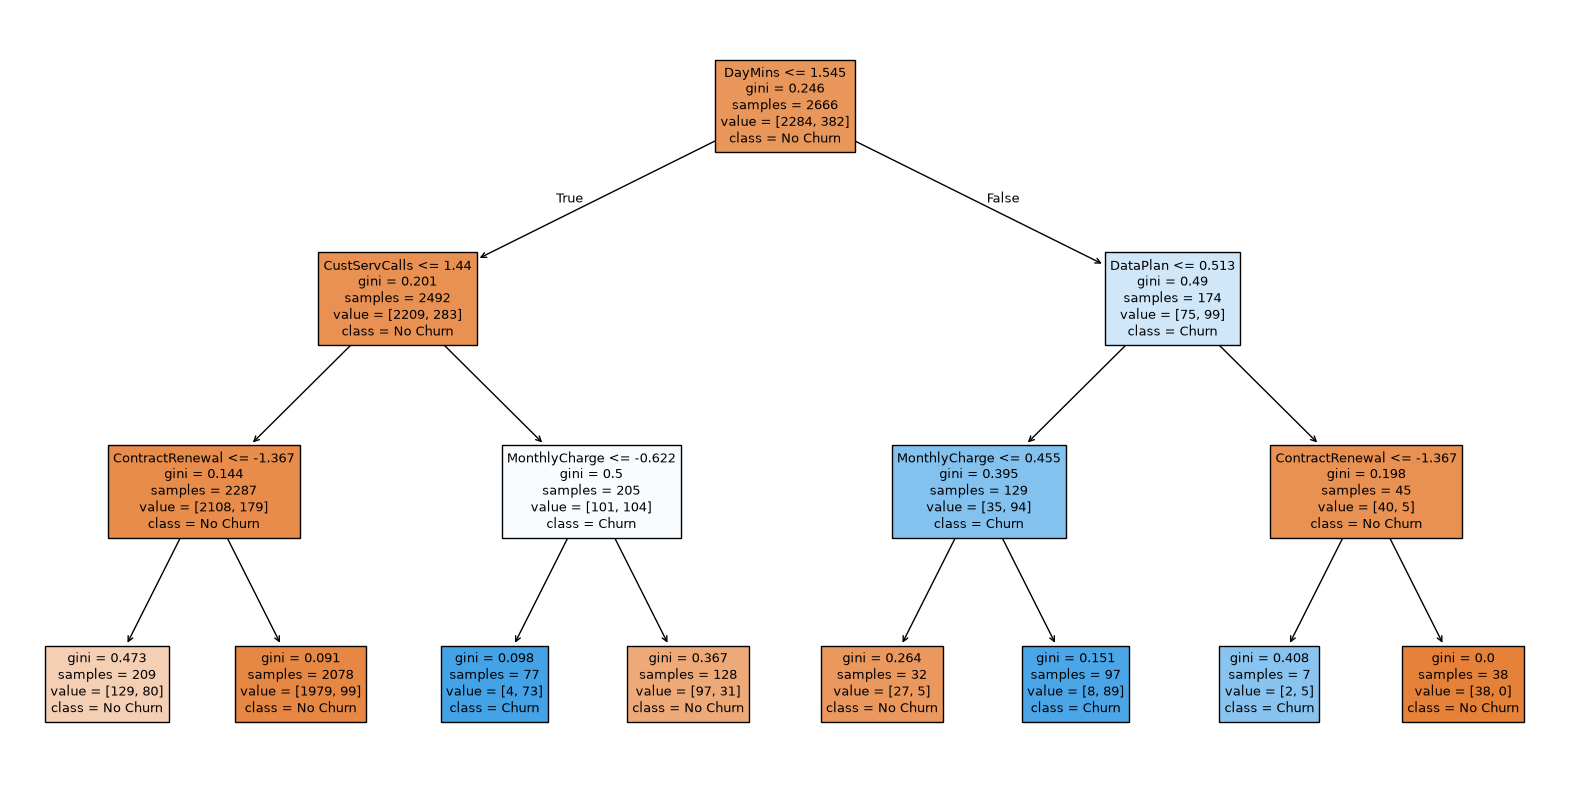

In [28]:
# visualize the tree structure
plt.figure(figsize=(20,10))
plot_tree(dt_pipeline.named_steps['model'], filled=True, feature_names=numerical_columns, class_names=['No Churn', 'Churn'])
plt.show()
# train vs test accuracy
train_accuracy = dt_pipeline.score(X_train, y_train)

In [29]:
dt_low_depth = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', DecisionTreeClassifier(max_depth=2))
])

dt_low_depth.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['AccountWeeks','ContractRenewal','DataPlan',...,'MonthlyCharge', 'OverageFee','RoamMins']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [30]:
dt_high_depth = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', DecisionTreeClassifier(max_depth=10))
])

dt_high_depth.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['AccountWeeks','ContractRenewal','DataPlan',...,'MonthlyCharge', 'OverageFee','RoamMins']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [32]:
y_pred_low_depth = dt_low_depth.predict(X_test)
y_pred_high_depth = dt_high_depth.predict(X_test)

train_accuracy_low_depth = dt_low_depth.score(X_train, y_train)
train_accuracy_high_depth = dt_high_depth.score(X_train, y_train)

test_accuracy_low_depth = dt_low_depth.score(X_test, y_test)    
test_accuracy_high_depth = dt_high_depth.score(X_test, y_test)

print(f"Train Accuracy (Low Depth): {train_accuracy_low_depth}")
print(f"Train Accuracy (High Depth): {train_accuracy_high_depth}")

print(f"Test Accuracy (Low Depth): {test_accuracy_low_depth}")
print(f"Test Accuracy (High Depth): {test_accuracy_high_depth}")

print(classification_report(y_test, y_pred_low_depth))
print(classification_report(y_test, y_pred_high_depth))

Train Accuracy (Low Depth): 0.8799699924981246
Train Accuracy (High Depth): 0.9696174043510878
Test Accuracy (Low Depth): 0.8860569715142429
Test Accuracy (High Depth): 0.9100449775112444
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       566
           1       0.66      0.50      0.57       101

    accuracy                           0.89       667
   macro avg       0.79      0.73      0.75       667
weighted avg       0.88      0.89      0.88       667

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       566
           1       0.77      0.57      0.66       101

    accuracy                           0.91       667
   macro avg       0.85      0.77      0.80       667
weighted avg       0.90      0.91      0.90       667



## PART 2 — Model Validation & Cross-Validation

**Task 3: Train vs Validation vs Test Split**

1. Split data into:
   - Training set
   - Validation set
   - Test set
2. Train model on training data.
3. Tune one simple parameter using validation set.
4. Evaluate final model on test set.


In [33]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

X_train.shape, X_val.shape, y_train.shape, y_val.shape, X_test.shape, y_test.shape


((2132, 10), (534, 10), (2132,), (534,), (667, 10), (667,))

In [34]:
# tune the dt pipeline
dt_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', DecisionTreeClassifier(max_depth=3))
])

dt_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['AccountWeeks','ContractRenewal','DataPlan',...,'MonthlyCharge', 'OverageFee','RoamMins']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [38]:
depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]
best_depth = None
best_val_acc = 0

for depth in depths:
    model = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', DecisionTreeClassifier(max_depth=depth))
    ])
    model.fit(X_train, y_train)
    val_acc = model.score(X_val, y_val)
    print(f"max_depth={depth}, val accuracy={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_depth = depth

print("Best max_depth:", best_depth)
print("Best validation accuracy:", best_val_acc)

max_depth=2, val accuracy=0.8745
max_depth=3, val accuracy=0.8820
max_depth=4, val accuracy=0.9064
max_depth=5, val accuracy=0.9120
max_depth=6, val accuracy=0.9064
max_depth=7, val accuracy=0.8970
max_depth=8, val accuracy=0.8989
max_depth=9, val accuracy=0.8951
max_depth=10, val accuracy=0.8970
Best max_depth: 5
Best validation accuracy: 0.9119850187265918


In [39]:
final_model = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', DecisionTreeClassifier(max_depth=best_depth))
])

final_model.fit(X_train, y_train)

test_accuracy = final_model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

print(classification_report(y_test, final_model.predict(X_test)))

Test Accuracy: 0.9055
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       566
           1       0.80      0.50      0.62       101

    accuracy                           0.91       667
   macro avg       0.86      0.74      0.78       667
weighted avg       0.90      0.91      0.90       667



**Task 4: Cross-Validation**

1. Apply K-Fold Cross Validation (k=5).
2. Compute average accuracy.
3. Compare single train-test accuracy vs cross-validation accuracy.

In [41]:
from sklearn.model_selection import KFold, cross_val_score

In [42]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(final_model, X_train, y_train, cv=kf)
scores
    

array([0.88290398, 0.96487119, 0.92488263, 0.92488263, 0.9342723 ])

In [44]:
print(f"Cross-Validation Accuracy: {scores.mean():.4f}")
print(f"Single Train-Test Accuracy: {final_model.score(X_test, y_test):.4f}")

Cross-Validation Accuracy: 0.9264
Single Train-Test Accuracy: 0.9055


## PART 3 — Ensemble Learning

**Task 5: Bagging vs Boosting (Conceptual + Practical)**

1. Briefly explain:
   - Bagging
   - Boosting
2. Train:
   - Bagging Classifier
   - AdaBoost Classifier
3. Compare their performance.

### 5.1 — Bagging vs Boosting (my understanding)

**Bagging (Bootstrap Aggregating)**
- You train a bunch of models (usually the same type, like decision trees) on different random samples of the training data. The samples are bootstrapped — meaning you pick rows with replacement, so some rows show up more than once and some get left out.
- Each model learns on its own chunk of data. At prediction time you combine them — for classification it's usually majority vote.
- Main idea: individual models might overfit or be noisy, but averaging/voting smooths that out. So bagging mainly helps **reduce variance**.
- Models are trained **in parallel** (they don't depend on each other). Random Forest is basically bagging with decision trees.

**Boosting**
- Here models are trained **one after another**, not all at once.
- The first model makes mistakes → the next model pays more attention to those wrong predictions (AdaBoost does this with sample weights).
- Each new weak learner tries to fix what the previous ones got wrong. Final prediction is a weighted combo of all of them.
- Main idea: turn a bunch of weak models into one strong model. Boosting mainly helps **reduce bias**.
- Can overfit if you add too many estimators or the base model is too complex.

**Quick difference:** bagging = train many models independently and vote. boosting = train models sequentially, each one focusing on previous errors.

In [46]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

In [48]:

bagging_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=10))
])
adaboost_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=10))
])

bagging_pipeline.fit(X_train, y_train)
adaboost_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['AccountWeeks','ContractRenewal','DataPlan',...,'MonthlyCharge', 'OverageFee','RoamMins']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passt

In [51]:
bagging_accuracy = bagging_pipeline.score(X_test, y_test)
adaboost_accuracy = adaboost_pipeline.score(X_test, y_test)

print(f"Bagging Accuracy: {bagging_accuracy:.4f}")
print(f"AdaBoost Accuracy: {adaboost_accuracy:.4f}")

print("Bagging Classification Report:")
print(classification_report(y_test, bagging_pipeline.predict(X_test)))
print("AdaBoost Classification Report:")
print(classification_report(y_test, adaboost_pipeline.predict(X_test)))


Bagging Accuracy: 0.8921
AdaBoost Accuracy: 0.9235
Bagging Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       566
           1       0.89      0.33      0.48       101

    accuracy                           0.89       667
   macro avg       0.89      0.66      0.71       667
weighted avg       0.89      0.89      0.87       667

AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       566
           1       0.84      0.61      0.71       101

    accuracy                           0.92       667
   macro avg       0.89      0.80      0.83       667
weighted avg       0.92      0.92      0.92       667




**Task 6: Random Forest (Bagging)**

1. Train a Random Forest Classifier.
2. Compare performance with:
   - Single Decision Tree
   - Bagging Classifier
3. Print feature importance.


In [52]:
from sklearn.ensemble import RandomForestClassifier

In [54]:
rf_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('model', RandomForestClassifier(n_estimators=10, max_depth=3))
])

rf_pipeline.fit(X_train, y_train)

rf_accuracy = rf_pipeline.score(X_test, y_test)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Single Decision Tree Accuracy: {dt_pipeline.score(X_test, y_test):.4f}")
print(f"Bagging Accuracy: {bagging_pipeline.score(X_test, y_test):.4f}")

print(classification_report(y_test, rf_pipeline.predict(X_test)))


Random Forest Accuracy: 0.8921
Single Decision Tree Accuracy: 0.8966
Bagging Accuracy: 0.8921
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       566
           1       0.89      0.33      0.48       101

    accuracy                           0.89       667
   macro avg       0.89      0.66      0.71       667
weighted avg       0.89      0.89      0.87       667



In [ ]:
print("feature importance:")
print(rf_pipeline.named_steps['model'].feature_importances_)